# MNIST, Convolutional Neural Network (CNN)

# Step - 1

### MNIST由手寫阿拉伯數字組成，包含60,000個訓練樣本和10,000個測試樣本。

##### data from: https://keras.io/datasets/#mnist-database-of-handwritten-digits
##### code modified from: TensorFlow+Keras[深度學習]人工智慧實務應用 / 林大貴


# (1) Import the data from Keras

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# for tensorflow 2.0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import optimizers
from tensorflow import keras

In [3]:
np.random.seed(3)

In [4]:
# Dataset of 60,000 28x28 grayscale images of the 10 digits, along with a test set of 10,000 images.

(x_train_image, y_train_label), (x_test_image, y_test_label) = keras.datasets.mnist.load_data()

print(x_train_image.shape)
print(y_train_label.shape)
print(x_test_image.shape)
print(y_test_label.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


# (2) View the first 10 images and labels

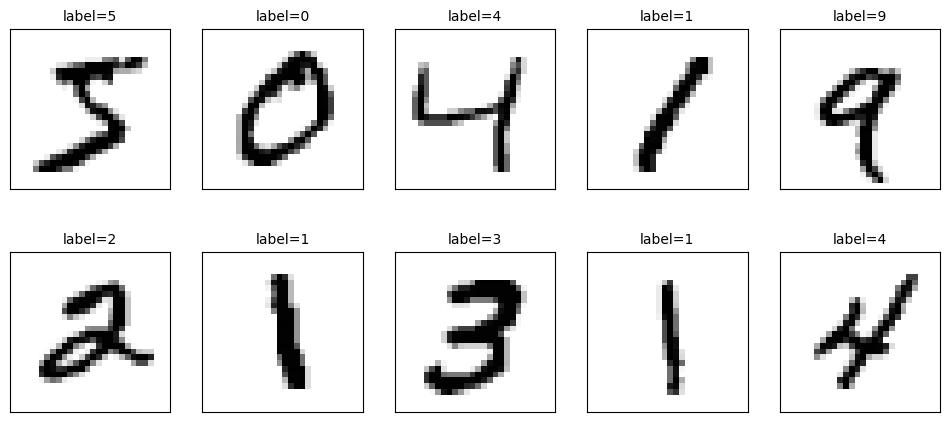

In [5]:
fig = plt.gcf()
fig.set_size_inches(12,14)

for i in range(0,10):
    ax=plt.subplot(5,5,1+i)
    ax.imshow(x_train_image[i], cmap='binary')
    title= "label=" +str(y_train_label[i])
    ax.set_title(title,fontsize=10) 
    ax.set_xticks([]);ax.set_yticks([])        
plt.show()

# (3) Convert 2-D image to nx28x28x1 array, normalize the numbers

In [6]:
# convert 2-D 28x28 image to 1-D 784 array
# x_Train =x_train_image.reshape(60000, 784).astype('float32')
# x_Test = x_test_image.reshape(10000, 784).astype('float32')

# convert 2-D 28x28 image to 4-D nx28x28x1  array
x_Train4D=x_train_image.reshape(x_train_image.shape[0],28,28,1).astype('float32')
x_Test4D=x_test_image.reshape(x_test_image.shape[0],28,28,1).astype('float32')

In [7]:
# normalize the image numbers to 0~1

x_Train4D_normalize = x_Train4D / 255
x_Test4D_normalize = x_Test4D / 255
print(x_Train4D_normalize.shape)
print(x_Test4D_normalize.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


# (4) Convert label number to one-hot encoding

In [8]:
# convert label numbers to one-hot encoding
y_TrainOneHot = to_categorical(y_train_label)
y_TestOneHot = to_categorical(y_test_label)
print(y_TrainOneHot.shape)
print(y_TestOneHot.shape)

(60000, 10)
(10000, 10)


# (5) Use a Convolutional Neural Network

In [9]:
model = Sequential()

In [10]:
model.add(Conv2D(filters=16,
                 kernel_size=(5,5),
                 padding='same',
                 input_shape=(28,28,1), 
                 activation='relu'))

In [11]:
# Enable this cell in the second step

# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Conv2D(filters=36,
#                 kernel_size=(5,5),
#                 padding='same',
#                 activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Dropout(0.25))

In [12]:
model.add(Flatten())

In [13]:
# Enable this cell in the second step

# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.5))

In [14]:
model.add(Dense(10,activation='softmax'))

In [15]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 16)        416       
                                                                 
 flatten (Flatten)           (None, 12544)             0         
                                                                 
 dense (Dense)               (None, 10)                125450    
                                                                 
Total params: 125866 (491.66 KB)
Trainable params: 125866 (491.66 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


# (6) Model training

有的版本用 acc and val_acc, 有的版本用 accuracy and val_accuracy.

Fixing the KeyError: ‘acc’ and KeyError: ‘val_acc’ Errors in Keras 2.3.x or Newer If you’re getting errors such as KeyError: ‘acc’ or KeyError: ‘val_acc’ in your Keras code, it may be due to a recent change in Keras 2.3.x.

https://towardsdatascience.com/fixing-the-keyerror-acc-and-keyerror-val-acc-errors-in-keras-2-3-x-or-newer-b29b52609af9

In [16]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',metrics=['accuracy']) 

In [17]:
train_history=model.fit(x=x_Train4D_normalize, 
                        y=y_TrainOneHot,validation_split=0.2, 
                        epochs=10, batch_size=300,verbose=2)

Epoch 1/10
160/160 - 7s - loss: 0.4142 - accuracy: 0.8879 - val_loss: 0.1665 - val_accuracy: 0.9555 - 7s/epoch - 43ms/step
Epoch 2/10
160/160 - 6s - loss: 0.1344 - accuracy: 0.9621 - val_loss: 0.1035 - val_accuracy: 0.9721 - 6s/epoch - 40ms/step
Epoch 3/10
160/160 - 6s - loss: 0.0894 - accuracy: 0.9753 - val_loss: 0.0927 - val_accuracy: 0.9737 - 6s/epoch - 38ms/step
Epoch 4/10
160/160 - 6s - loss: 0.0699 - accuracy: 0.9806 - val_loss: 0.0758 - val_accuracy: 0.9791 - 6s/epoch - 40ms/step
Epoch 5/10
160/160 - 6s - loss: 0.0591 - accuracy: 0.9829 - val_loss: 0.0684 - val_accuracy: 0.9808 - 6s/epoch - 40ms/step
Epoch 6/10
160/160 - 6s - loss: 0.0510 - accuracy: 0.9853 - val_loss: 0.0668 - val_accuracy: 0.9815 - 6s/epoch - 39ms/step
Epoch 7/10
160/160 - 7s - loss: 0.0452 - accuracy: 0.9871 - val_loss: 0.0631 - val_accuracy: 0.9827 - 7s/epoch - 42ms/step
Epoch 8/10
160/160 - 6s - loss: 0.0394 - accuracy: 0.9883 - val_loss: 0.0666 - val_accuracy: 0.9814 - 6s/epoch - 39ms/step
Epoch 9/10
160/1

# (7) Training history

In [18]:
def show_train_history(train_history,train,validation):
    plt.plot(train_history.history[train])
    plt.plot(train_history.history[validation])
    plt.title('Train History')
    plt.ylabel(train)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

有的版本用 acc and val_acc, 有的版本用 accuracy and val_accuracy.

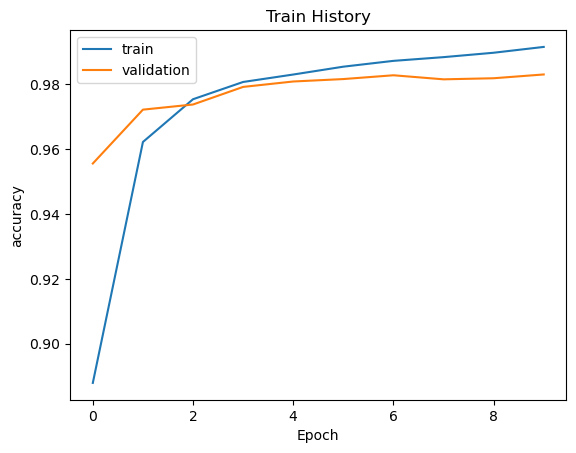

In [19]:
show_train_history(train_history,'accuracy','val_accuracy')

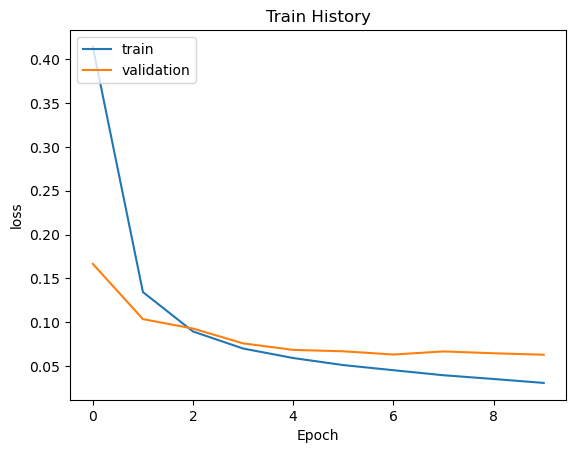

In [20]:
show_train_history(train_history,'loss','val_loss')

# (8) Accuracy

In [21]:
scores = model.evaluate(x_Test4D_normalize, y_TestOneHot)
print()
print('accuracy=',scores[1])

313/313 [==============================] - 1s 3ms/step - loss: 0.0511 - accuracy: 0.9841

accuracy= 0.9840999841690063


# (9) Prediction

In [22]:
predict_prob = model.predict(x_Test4D_normalize) 
prediction = np.argmax(predict_prob,axis=1)
print(prediction)

313/313 [==============================] - 1s 2ms/step
[7 2 1 ... 4 5 6]


In [23]:
def plot_images_labels_prediction(images,labels,prediction,
                                  idx,num=10):
    fig = plt.gcf()
    fig.set_size_inches(12, 14)
    if num>25: num=25 
    for i in range(0, num):
        ax=plt.subplot(5,5, 1+i)
        ax.imshow(images[idx], cmap='binary')
        title= "label=" +str(labels[idx])
        if len(prediction)>0:
            title+=",predict="+str(prediction[idx]) 
            
        ax.set_title(title,fontsize=10) 
        ax.set_xticks([]);ax.set_yticks([])        
        idx+=1 
    plt.show()

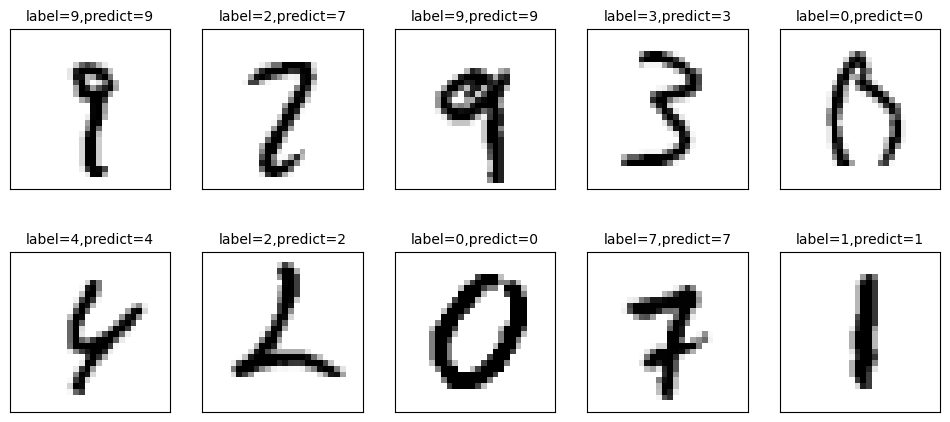

In [24]:
plot_images_labels_prediction(x_test_image,y_test_label,
                              prediction,idx=320)

# (10) Confusion matrix

In [25]:
pd.crosstab(y_test_label,prediction,
            rownames=['label'],colnames=['predict'])

predict,0,1,2,3,4,5,6,7,8,9
label,,,,,,,,,,
0,972,0,2,1,0,1,2,1,1,0
1,0,1128,1,1,1,1,2,1,0,0
2,1,2,1015,3,1,0,0,6,4,0
3,0,0,3,998,0,3,0,3,3,0
4,0,0,1,0,968,0,1,0,1,11
5,2,0,2,9,0,869,4,2,2,2
6,5,2,0,0,4,2,942,0,3,0
7,1,1,7,5,0,0,0,1010,1,3
8,5,0,4,3,0,1,1,7,950,3
